**Libraries**

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier

**Load dataset**

In [46]:
iris=load_iris()

**Create dataframe**

In [47]:
df=pd.DataFrame(iris.data,columns=iris.feature_names)
df['target']=iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


**Features and Targets**

In [48]:
X=df.drop('target',axis='columns')
y=df['target']

**Train Test Split**

In [49]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

**Model**

In [50]:
model1=RandomForestClassifier()
model1.fit(X_train,y_train)
print(model1.score(X_test,y_test))

1.0


**Model with 30 Tree**

In [51]:
model2=RandomForestClassifier(n_estimators=20)
model2.fit(X_train,y_train)
print(model2.score(X_test,y_test))

1.0


**Tree Count**

In [52]:
scores={}

In [53]:
for n in range(1,101):
  model=RandomForestClassifier(n_estimators=n,random_state=42)
  model.fit(X_train,y_train)
  score=model.score(X_test,y_test)
  scores[n]=score

**Visualise Scores**

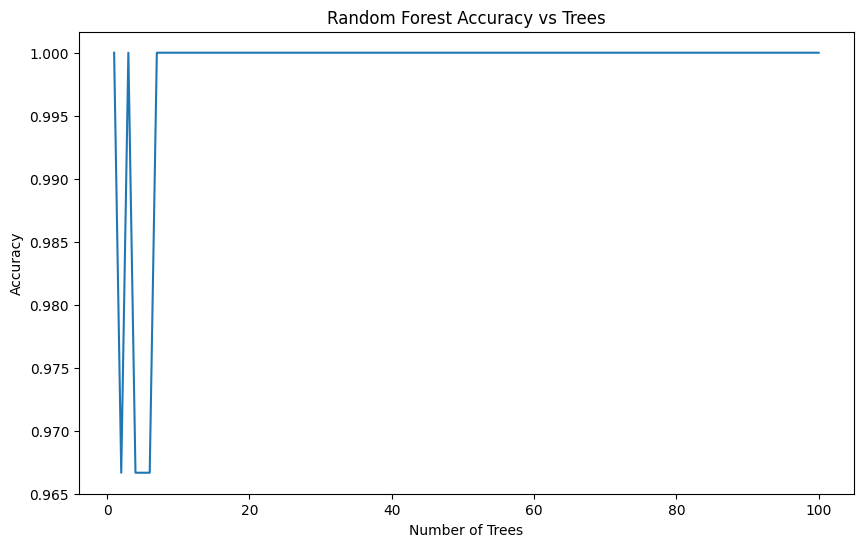

In [54]:
plt.figure(figsize=(10, 6))
plt.plot(list(scores.keys()), list(scores.values()))
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Random Forest Accuracy vs Trees")
plt.show()

**Best Model**

In [55]:
best_score=max(scores,key=scores.get)
print(best_score)

1


In [56]:
best_model=RandomForestClassifier(n_estimators=best_score,random_state=42)
best_model.fit(X_train,y_train)
predictions = best_model.predict(X_test)

**Confusion Matrix**

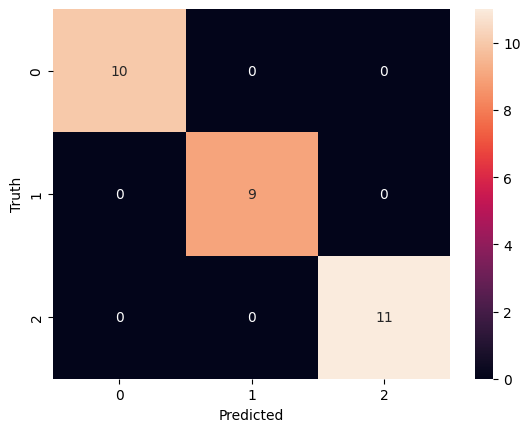

In [57]:
cm=confusion_matrix(y_test,predictions)
sn.heatmap(cm,annot=True)
plt.xlabel("Predicted")
plt.ylabel("Truth")
plt.show()